<a href="https://colab.research.google.com/github/agrawalpratibha63/gla-ml-session-sprint1/blob/main/Copy_of_Gla_ML_Session1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [ ]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
# Create a boolean column to  checking if the total score is 50 or higher
df['pass_status'] = df['total_score'] >= 50
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,pass_status
0,101,92,18,72,True,90,True,True
1,102,67,12,48,False,60,False,True
2,103,81,15,65,True,80,True,True
3,104,45,8,30,False,38,False,False
4,105,74,14,55,True,69,False,True
5,106,88,19,80,True,99,True,True


In [ ]:
def assign_grade(score):

    if score >= 80:

        return 'A'

    elif score >= 60:

        return 'B'

    elif score >= 50:

        return 'C'

    else:

        return 'F'
df['grade'] = df['total_score'].apply(assign_grade)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,pass_status,grade
0,101,92,18,72,True,90,True,True,A
1,102,67,12,48,False,60,False,True,B
2,103,81,15,65,True,80,True,True,A
3,104,45,8,30,False,38,False,False,F
4,105,74,14,55,True,69,False,True,B
5,106,88,19,80,True,99,True,True,A


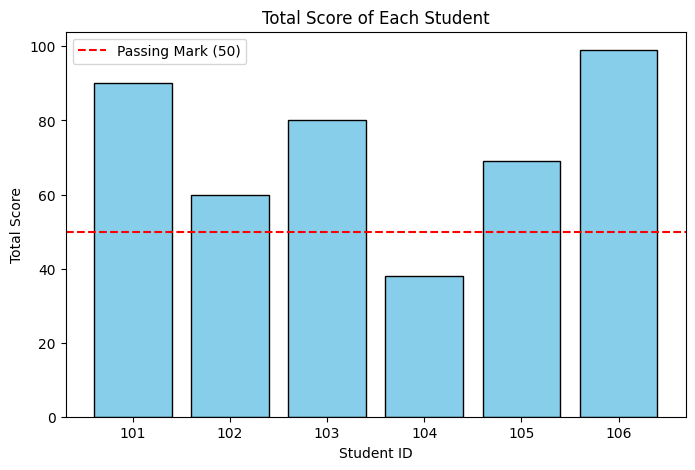

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

# Plotting the bar chart
plt.bar(df['student_id'].astype(str), df['total_score'], color='skyblue', edgecolor='black')

# Adding a horizontal line for the passing mark
plt.axhline(y=50, color='red', linestyle='--', label='Passing Mark (50)')

# Adding labels and title
plt.title('Total Score of Each Student')
plt.xlabel('Student ID')
plt.ylabel('Total Score')
plt.legend()

plt.show()

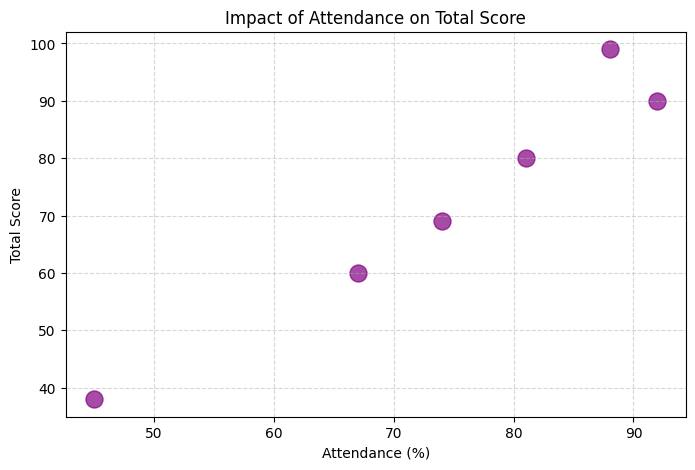

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

# Plotting the scatter plot
plt.scatter(df['attendance_percent'], df['total_score'], color='purple', s=150, alpha=0.7)

# Adding labels and title
plt.title('Impact of Attendance on Total Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Total Score')

# Adding a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

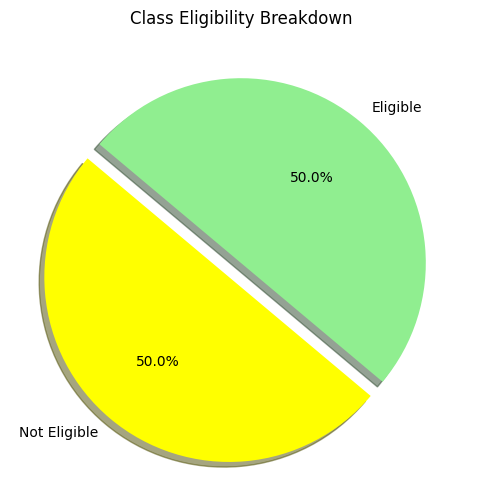

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))

# Counting the True/False values in the 'eligible' column
eligibility_counts = df['eligible'].value_counts()

# Plotting the pie chart
plt.pie(eligibility_counts.values,
        labels=['Not Eligible', 'Eligible'],
        autopct='%1.1f%%',
        colors=['yellow', 'lightgreen'],
        startangle=140,
        explode=(0.1, 0), # This slightly separates the slices
        shadow=True)

plt.title('Class Eligibility Breakdown')

plt.show()

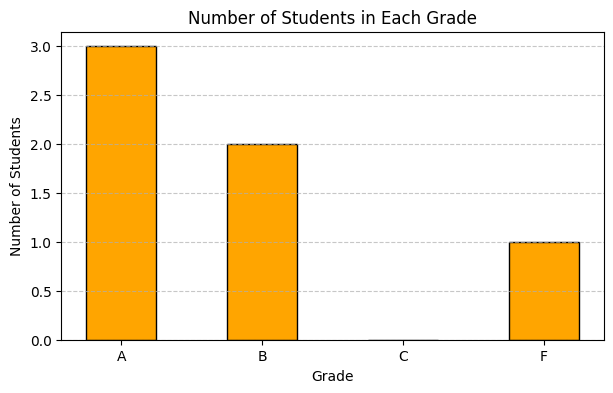

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

# Har ek grade ke students ko count karna (A, B, C, F ke sequence mein)
grade_counts = df['grade'].value_counts().reindex(['A', 'B', 'C', 'F'], fill_value=0)

# Bar graph plot karna
plt.bar(grade_counts.index, grade_counts.values, color='orange', edgecolor='black', width=0.5)

plt.title('Number of Students in Each Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Students')

# Sirf Y-axis par light grid lines add karna accuracy ke liye
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()